# **Basic Setup**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('student_habits_performance.csv')

In [3]:
print(data.head())

  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Master          Average  

In [5]:
print(data.shape)

(1000, 16)


In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

Statistical info of numerical attributes

In [7]:
print(data.describe())

             age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.0000           1000.00000         1000.000000    1000.000000   
mean     20.4980              3.55010            2.505500       1.819700   
std       2.3081              1.46889            1.172422       1.075118   
min      17.0000              0.00000            0.000000       0.000000   
25%      18.7500              2.60000            1.700000       1.000000   
50%      20.0000              3.50000            2.500000       1.800000   
75%      23.0000              4.50000            3.300000       2.525000   
max      24.0000              8.30000            7.200000       5.400000   

       attendance_percentage  sleep_hours  exercise_frequency  \
count            1000.000000  1000.000000         1000.000000   
mean               84.131700     6.470100            3.042000   
std                 9.399246     1.226377            2.025423   
min                56.000000     3.200000            0.

*   
*   
*   

# **Data Cleaning**

Removing inconsistencies in dataset

In [8]:
for col in data.columns:
  if data[col].dtype == 'object':
    data[col] = data[col].str.lower()
    data[col] = data[col].str.strip()

Checking nulls in dataset

In [9]:
print(data.isnull().sum())

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


Parental education level contains null values

In [10]:
print(data['parental_education_level'].value_counts())

parental_education_level
high school    392
bachelor       350
master         167
Name: count, dtype: int64


In [11]:
print(data['parental_education_level'].isnull().sum())

91


Finding percentage of missingness

In [12]:
print(data['parental_education_level'].isnull().mean() * 100, "%")

9.1 %


Checking how the missing values affect target attribute

In [13]:
print(data[data['parental_education_level'].isnull()]['exam_score'].describe())

count     91.000000
mean      70.034066
std       16.560181
min       30.200000
25%       59.800000
50%       71.000000
75%       81.200000
max      100.000000
Name: exam_score, dtype: float64


In [14]:
print(data[data['parental_education_level'].notnull()]['exam_score'].describe())

count    909.000000
mean      69.558196
std       16.929436
min       18.400000
25%       58.400000
50%       70.400000
75%       81.300000
max      100.000000
Name: exam_score, dtype: float64


Based on the analysis, the presence of null values does not appear to introduce bias or significantly alter the remaining data's characteristics. Therefore, removing rows with null values is a reasonable approach in this case.

Dropping rows with null values

In [15]:
data.dropna(inplace=True)

Dropping rows with missing 'parental_education_level' to ensure data quality.
Only 9.1% rows affected; negligible impact on analysis and cleaner results.

In [16]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     909 non-null    object 
 1   age                            909 non-null    int64  
 2   gender                         909 non-null    object 
 3   study_hours_per_day            909 non-null    float64
 4   social_media_hours             909 non-null    float64
 5   netflix_hours                  909 non-null    float64
 6   part_time_job                  909 non-null    object 
 7   attendance_percentage          909 non-null    float64
 8   sleep_hours                    909 non-null    float64
 9   diet_quality                   909 non-null    object 
 10  exercise_frequency             909 non-null    int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               909 non-null    object 


In [17]:
print(data.shape)

(909, 16)


In [18]:
print(data.duplicated().sum())

0


No duplicate entries..

# **Feature Engineering**

Creating a new column, 'total_screen_time' from 'social_media_hours' and 'netflix_hours'

In [19]:
data["total_screen_time"] = data['social_media_hours'] + data['netflix_hours']

In [20]:
print(data.columns)

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score',
       'total_screen_time'],
      dtype='object')


# **Descriptive Analysis**

# Univariate Analysis

Histogram for Age Attribute

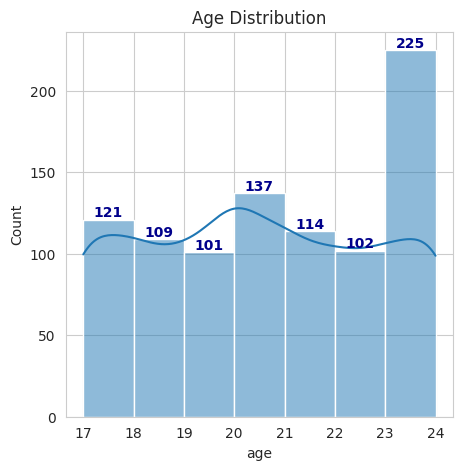

In [54]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['age'], kde=True, binwidth=1)
plt.title('Age Distribution')

for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=10, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontweight='bold')

*   The age distribution is unimodal and left-skewed, suggesting that the majority of individuals are concentrated in the older age range, with a less frequent representation of individuals in the younger age groups.
*   This suggests that most students in the dataset are nearing the end of their academic journey.

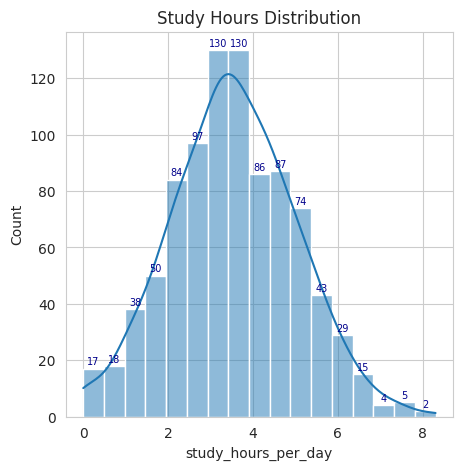

In [53]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['study_hours_per_day'], kde=True, binwidth=0.5)
plt.title('Study Hours Distribution')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=7, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')

*   The distribution is unimodal and approximately symmetric, though there is a slight right skew.
*   The most common study duration is between 3 to 4 hours per day, with the highest count (130 students each) in that range.
*   As study hours increase beyond 4, the number of students gradually decreases, showing that fewer students study longer hours.
*   Very few students study more than 6 hours per day, indicating a natural drop-off in high-effort study durations.



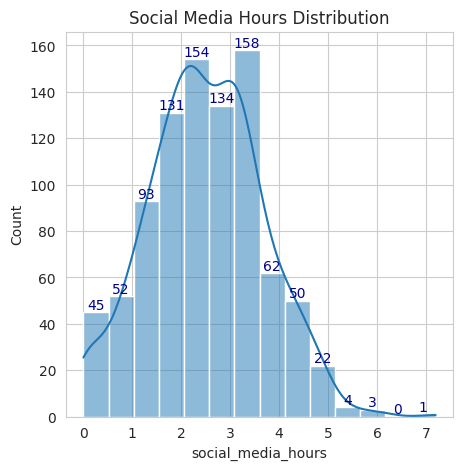

In [50]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['social_media_hours'], kde=True, binwidth = 0.5)
plt.title('Social Media Hours Distribution')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=10, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')



*   The distribution is bimodal and right-skewed.
*   This indicated there are two primary social media usage peaks, one at 2 hours and other at approximately 3.5 hours.
*   A substantial portion of students uses social media for 3.5 hours or less.
*   There is a steep drop in student count after 4 hours, showing that extended social media engagement is relatively rare.





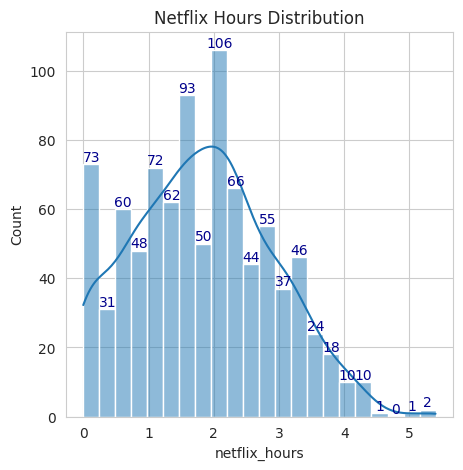

In [49]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['netflix_hours'], kde=True, binwidth=0.25)
plt.title('Netflix Hours Distribution')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=10, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')

*   This distribution is unimodal and right-skewed.
*   This indicates that a large number of students spend upto 2 to 2.5 hours od the day watching Netflix.
*   Mild fluctuations are observed in usage between 0 and 2 hours, though usage generally increases toward the peak at 2–2.5 hours.
*   A notable count at 0 hours suggests that many students don’t watch Netflix at all.
*   The usage sharply declines after 2 hours, showing fewer students indulge in prolonged binge-watching.

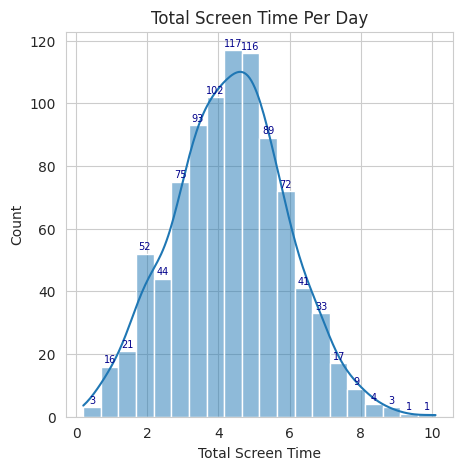

In [56]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['total_screen_time'], kde=True, binwidth=0.5)
plt.title('Total Screen Time Per Day')
plt.xlabel('Total Screen Time')
plt.ylabel('Count')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=7, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')

*   This distribution is also unimodal and right-skewed.
*   This indicated that most frequently observed total screen time (for entertainment), is around 4 to 5 hours.
*   It can be observed that studdents often spend more time on social media compared to time spent on Netflix
*   Although students vary in how they use their screen time, their overall screen exposure remains within a consistent range.

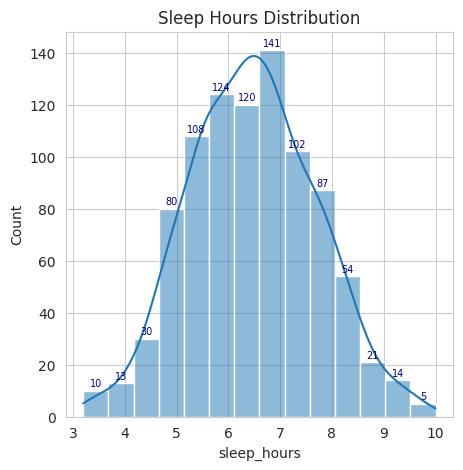

In [57]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['sleep_hours'], kde=True, binwidth=0.5)
plt.title('Sleep Hours Distribution')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=7, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')



*   The distribution is unimodal and closely follows a normal (bell-shaped) curve.
*   The most frequently observed sleep duration is around 7 hours per day.
*   A large portion of students sleep between 5 and 7 hours, which appears to be the typical sleep range.
*   The distribution appears nearly symmetric, reflecting a healthy spread of sleep duration without extreme outliers on either side.



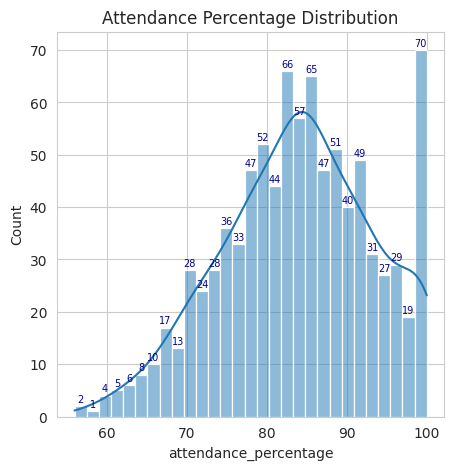

In [58]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['attendance_percentage'], kde=True, binwidth=1.5)
plt.title('Attendance Percentage Distribution')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=7, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')



*   This distribution is unimodal and left-skewed.
*   The most frequently observed attendance precentage ranges from 80% to 90%, indicating most of the students attend school for 80% of the working days.
*   This distribution also shows that there rea very few students who attend school less than 70%.
*   While there's a general decline after 90%, there’s a sudden spike at 100%, which may reflect students with perfect attendance — possibly due to school policies, awards, or disciplined habits.

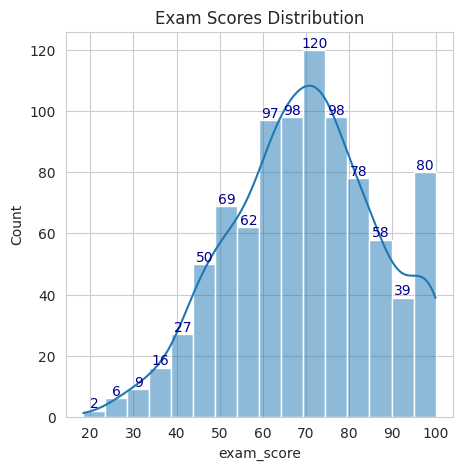

In [62]:
sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

ax = sns.histplot(data['exam_score'], kde=True, binwidth=5)
plt.title('Exam Scores Distribution')

for p in ax.patches:
        height = p.get_height()
        if height >= 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        fontsize=10, color='darkblue',
                        xytext=(0, 5),
                        textcoords='offset points')

*   This distribution is unimodal and left skewed.
*   Exam scores are distributed from 20 to 100, with a notable peak observed at 70 to 80 marks, indicating large number of students score around 70-80 marks in exams.
*   Scores below 40 are observed in only a few students, indicating a generally better academic performance overall.


Text(0.5, 1.0, 'Gender Distribution')

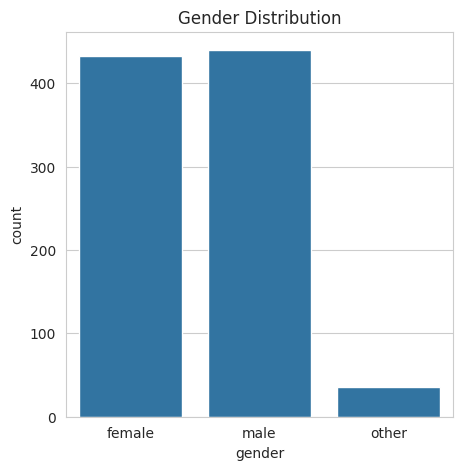

In [63]:
plt.figure(figsize=(5, 5))

sns.countplot(data=data, x = "gender")
plt.title("Gender Distribution")

The gender distribution in this dataset is fairly balanced between female and male students, with a significantly smaller representation of students identifying as other.

Text(0.5, 1.0, 'Parental Education Level Distribution')

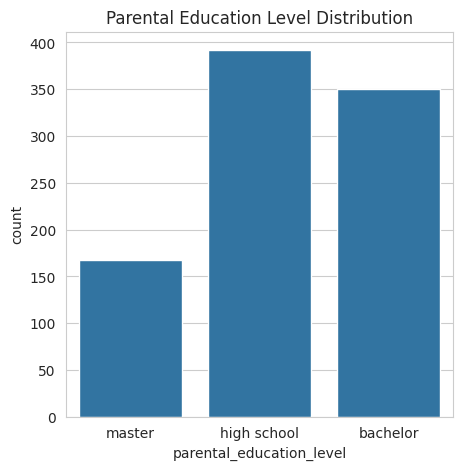

In [64]:
plt.figure(figsize=(5, 5))

sns.countplot(data = data, x="parental_education_level")
plt.title("Parental Education Level Distribution")

The highest count is observed for students whose parents have completed high school.

Text(0.5, 1.0, 'Diet Quality Distribution')

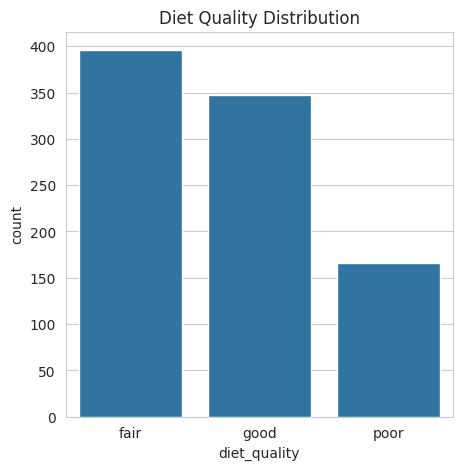

In [65]:
plt.figure(figsize=(5, 5))

sns.countplot(data=data, x="diet_quality")
plt.title("Diet Quality Distribution")

While a significant number of students maintain a proper diet, there is a considerable proportion with poor diet quality.

# Bivariate Analysis

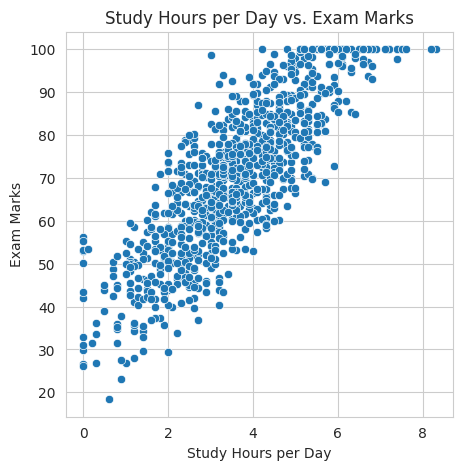

In [66]:
plt.figure(figsize=(5, 5))

sns.scatterplot(data = data, x='study_hours_per_day', y = "exam_score")
plt.title("Study Hours per Day vs. Exam Marks")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Marks")
plt.show()

*   As study hours per day increase, exam marks tend to increase. This suggests that more study time is associated with better exam performance.
*   The relationship between study hours and exam marks appears to be roughly linear. This means that the increase in exam marks for each additional hour of study is relatively consistent.
*   Most students score between 60 and 100.



Text(0, 0.5, 'Exam Marks')

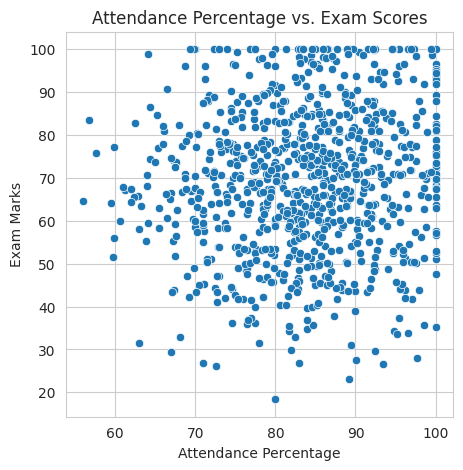

In [67]:
plt.figure(figsize=(5, 5))

sns.scatterplot(data = data, x = "attendance_percentage", y = "exam_score")
plt.title("Attendance Percentage vs. Exam Scores")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Marks")

*   The relationship between attendance percentage and exam scores is weak and does not exhibit a clear linear pattern. This suggests that exam scores are not strongly and consistently influenced by attendance percentage.
*   The presence of data points showing students with high exam scores despite low attendance, and vice versa, suggests that attendance percentage alone does not fully determine exam performance.
*   A student's exam performance appears to be influenced by factors beyond just attendance.

Text(0, 0.5, 'Marks in Exam')

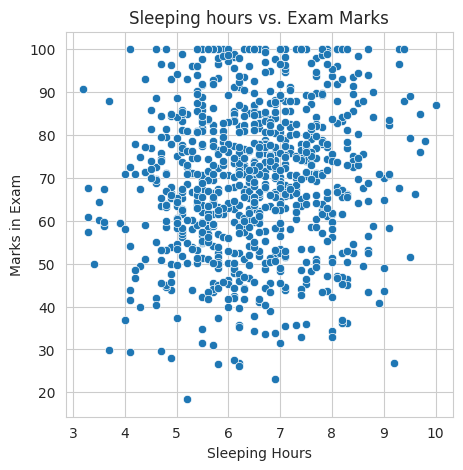

In [68]:
plt.figure(figsize=(5, 5))

sns.scatterplot(data=data, x = "sleep_hours", y = "exam_score")
plt.title("Sleeping hours vs. Exam Marks")
plt.xlabel("Sleeping Hours")
plt.ylabel("Marks in Exam")

Smiilar to the previous distribution, this also have a weak relationship and sleeping hours along can not determine the marks in exam.

Text(0, 0.5, 'Marks in Exam')

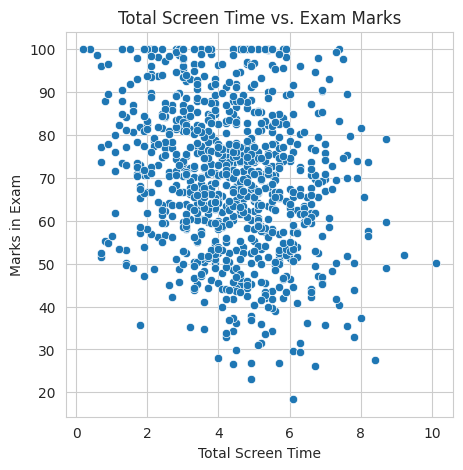

In [69]:
plt.figure(figsize=(5, 5))

sns.scatterplot(data = data, x = "total_screen_time", y = "exam_score")
plt.title("Total Screen Time vs. Exam Marks")
plt.xlabel("Total Screen Time")
plt.ylabel("Marks in Exam")

*   There is no linear relationship between total screen time and exam scores, indicating that a student's exam performance is not substantially influenced by their overall screen time.
*   While the majority of students exhibit a wide range of exam scores regardless of their screen time, there are a few students with higher screen times who still achieve relatively high exam scores.



Text(0, 0.5, 'Exam Marks')

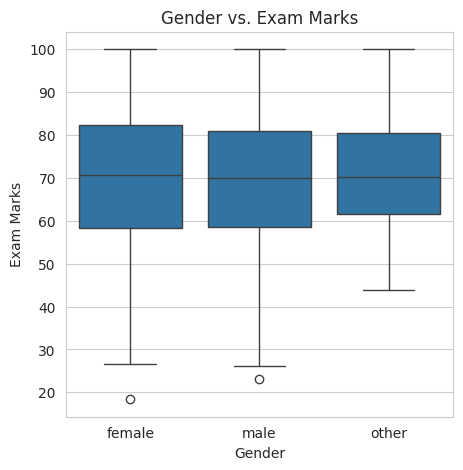

In [70]:
plt.figure(figsize=(5, 5))

sns.boxplot(data=data, x='gender', y = 'exam_score')
plt.title("Gender vs. Exam Marks")
plt.xlabel("Gender")
plt.ylabel("Exam Marks")

*   The distribution of exam scores is broadly similar across male, female, and other gender categories, suggesting that gender is not a primary factor in explaining differences in exam performance.
*   The presence of a few lower-scoring outliers is observed across all gender categories, highlighting that low achievement is not specific to any particular gender.



Text(0, 0.5, 'Exam Marks')

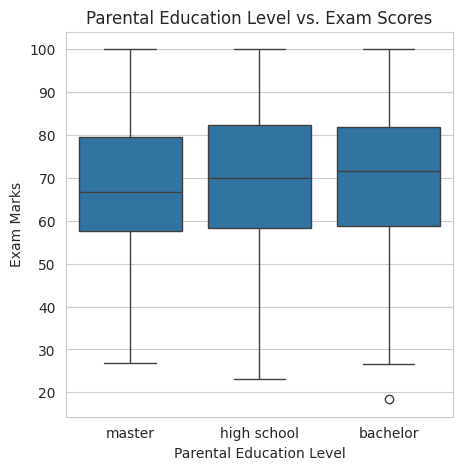

In [71]:
plt.figure(figsize=(5, 5))

sns.boxplot(data=data, x = "parental_education_level", y = "exam_score")
plt.title("Parental Education Level vs. Exam Scores")
plt.xlabel("Parental Education Level")
plt.ylabel("Exam Marks")

*   The median exam scores are relatively consistent across all three parental education levels — High School, Bachelor’s, and Master’s. This indicates that a student's average performance does not significantly vary based on their parents' education level.
*   Each category shows a few low-scoring outliers, suggesting that low exam scores occurs in all parental education groups. This indicates that exam scores are influenced by multiple factors beyond parental education alone.



Text(0, 0.5, 'Exam Marks')

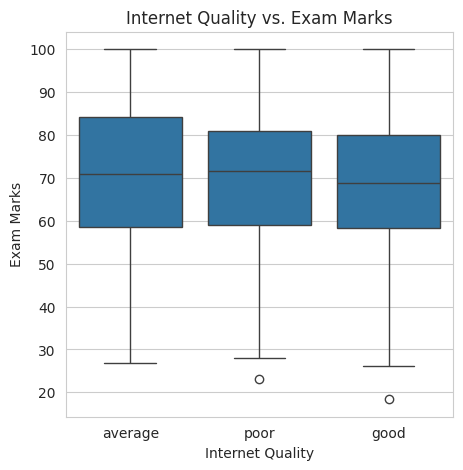

In [48]:
plt.figure(figsize=(5, 5))

sns.boxplot(data = data, x = 'internet_quality', y = 'exam_score')
plt.title("Internet Quality vs. Exam Marks")
plt.xlabel("Internet Quality")
plt.ylabel("Exam Marks")

*   The median exam score is roughly similar across all the three catagories of internet quality.
*   The presence of low-scoring outliers in both the 'poor' and 'good' internet quality groups indicates that exam performance is influenced by factors beyond internet quality. While it may have some impact, it is clearly not the sole determinant of student outcomes.

# Multivariate Analysis

Changing the sequence of the columns by placing 'total_screen_time' after 'netflix_hours' for better insights.

In [72]:
cols = data.columns.tolist()
new_order = ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'total_screen_time',
             'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level',
             'internet_quality', 'mental_health_rating', 'exam_score']
data = data[new_order]
print(data.columns)

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'total_screen_time',
       'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'exam_score'],
      dtype='object')


In [43]:
numeric_data = data.select_dtypes(include='number')

In [44]:
corr_matrix = numeric_data.corr()

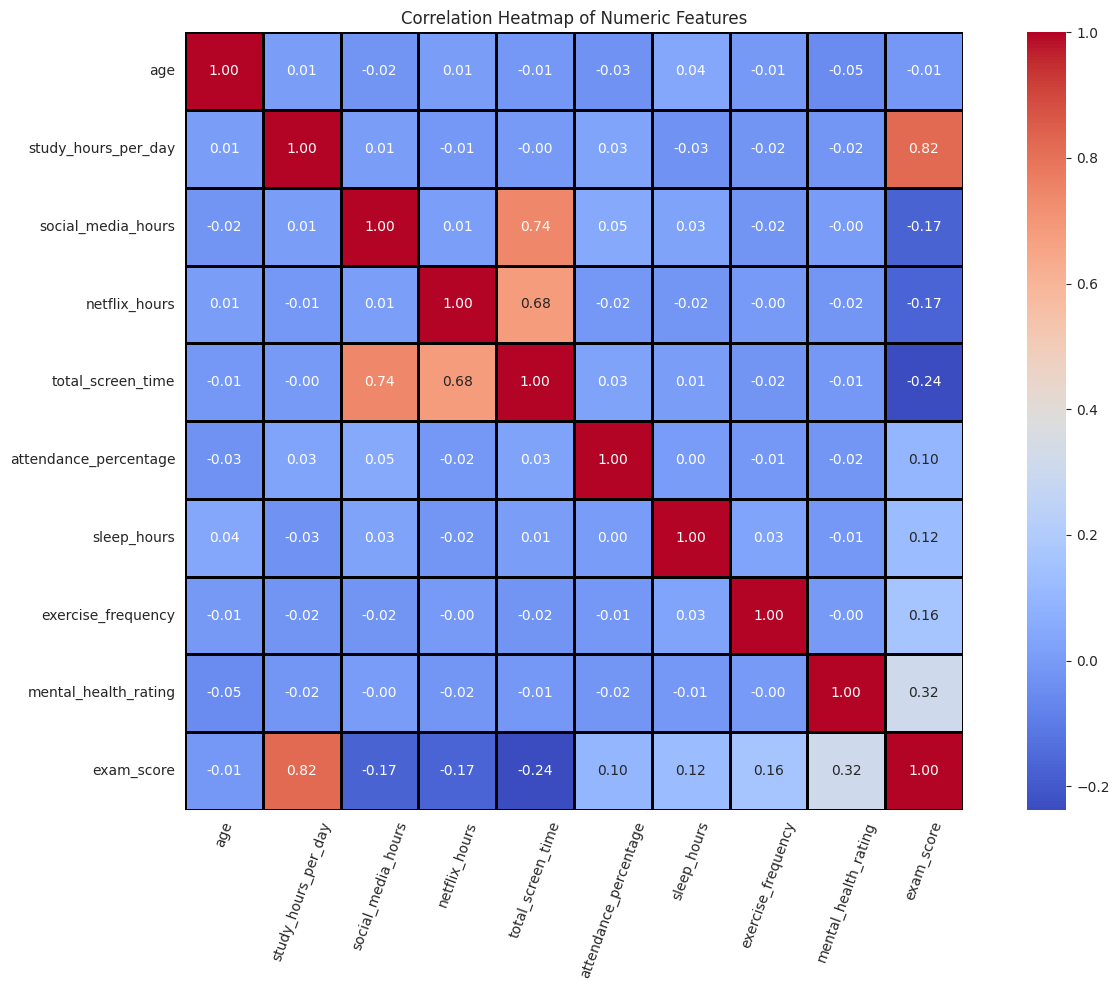

In [78]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=1,
            linecolor='black',
            square=True)

plt.title("Correlation Heatmap of Numeric Features")
plt.xticks(rotation=70)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Strong Positive Correlation
*   Students who study more consistently (more number of hours) tend to achieve higher exam scores — the strongest relationship in the dataset.

### Moderate Negative Correlation
*   There is a slight negative correlation between total screen time and exam scores, indicating that students who spend more time on screens tend to perform slightly worse academically.

### Moderate Positive Correlation
*   The moderate positive correlation between mental health rating and exam scores indicates students who report better mental health tend to score higher on exams.

# **Key Insights from Student Habits vs. Academic Performance Analysis**

####1. Study hours are the strongest predictor of exam performance.
####2. Increased screen time is weakly linked to lower exam scores.
####3. Better mental health is moderately associated with better academic outcomes.
####4. Other factors such as age, sleep, exercise, attendance, and parental education show weak correlations with exam scores.

# **Recommendations for Academic Improvement**

####1. Encourage regular study habits — structured study time has the most impact on academic performance.
####2. Educate students on managing screen time, especially non-academic usage like Netflix and social media.
####3. Support mental health initiatives, as psychological well-being contributes to performance.